# Waymo Feature Extraction v2: Day/Night Comparison

This notebook compares the original training features, which contain both daytime and nighttime sequences, with a daytime-only subset.

It performs the following steps:

1. Classifies each training sequence as day or night from its first frame using the function and `0.30` threshold from `filter_day_night.ipynb`.
2. Loads the original HOG, HSV, YOLO, and road-geometry arrays.
3. Selects daytime rows without recomputing the feature values.
4. Saves the daytime-only arrays with `_v2` filenames so none of the original feature files are overwritten.
5. Plots class balance and a two-row PCA comparison using common PCA axes.
6. Compares out-of-fold classification performance by lighting condition, feature set, and maneuver class.

The feature arrays contain one target image per sequence. Lighting is assigned at the sequence level from the sequence's first available frame, matching the filtering approach in `filter_day_night.ipynb`.

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter
from IPython.display import display


# Allow the notebook to run from either the project root or a notebooks folder.
current_dir = Path.cwd().resolve()

if (current_dir / 'data').exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / 'data').exists():
    PROJECT_ROOT = current_dir.parent
else:
    raise FileNotFoundError(
        "Could not find the data folder. Run this notebook from the project root "
        "or from a folder directly inside the project root."
    )

DATA_DIR = PROJECT_ROOT / 'data'
TRAIN_DIR = DATA_DIR / 'processed' / 'waymo_e2e' / 'training'
MANIFEST_PATH = DATA_DIR / 'train_manifest.json'
FEATURES_DIR = DATA_DIR / 'processed' / 'waymo_e2e' / 'features'
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = [
    'straight',
    'left-turn',
    'right-turn',
    'lane-change-left',
    'lane-change-right',
]

COLORS = {
    'straight': 'steelblue',
    'left-turn': 'tomato',
    'right-turn': 'green',
    'lane-change-left': 'purple',
    'lane-change-right': 'orange',
}

DAY_THRESHOLD = 0.30
RANDOM_STATE = 42
CV_FOLDS = 3  # Faster while retaining stratified held-out predictions.

# These are the existing arrays created by waymo_feature_extraction.ipynb.
ORIGINAL_FILES = {
    'hog': 'hog.npy',
    'hsv': 'hsv.npy',
    'labels': 'labels.npy',
    'road': 'road.npy',
    'seq_ids': 'seq_ids.npy',
    'yolo': 'yolo.npy',
}

# These are the new daytime-only arrays
V2_FILES = {
    'hog': 'hog_v2.npy',
    'hsv': 'hsv_v2.npy',
    'labels': 'labels_v2.npy',
    'road': 'road_v2.npy',
    'seq_ids': 'seq_ids_v2.npy',
    'yolo': 'yolo_v2.npy',
}

# Protect against accidentally assigning an original filename to a v2 output.
assert set(ORIGINAL_FILES.values()).isdisjoint(V2_FILES.values())

print(f'Project root:  {PROJECT_ROOT}')
print(f'Training data: {TRAIN_DIR}')
print(f'Feature files: {FEATURES_DIR}')

Project root:  C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final
Training data: C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final\data\processed\waymo_e2e\training
Feature files: C:\Users\Matt\Desktop\Cal MIDS Program\Summer 2026\DATASCI 281\Final Project\281-s2-group2-final\data\processed\waymo_e2e\features


## Load the manifest and original features

The original arrays are required because the daytime-only arrays are created as an exact subset. This prevents small differences caused by rerunning stochastic or version-dependent models such as YOLO.

In [2]:
with open(MANIFEST_PATH, 'r') as f:
    manifest = json.load(f)

missing_files = [
    filename
    for filename in ORIGINAL_FILES.values()
    if not (FEATURES_DIR / filename).exists()
]

if missing_files:
    raise FileNotFoundError(
        'The following original feature files are missing:\n  ' +
        '\n  '.join(missing_files) +
        '\nRun the original feature extraction notebook first.'
    )

original_arrays = {
    name: np.load(
        FEATURES_DIR / filename,
        allow_pickle=name in {'labels', 'seq_ids'}
    )
    for name, filename in ORIGINAL_FILES.items()
}

# Standardize string arrays before matching them to the manifest and class list.
original_arrays['labels'] = original_arrays['labels'].astype(str)
original_arrays['seq_ids'] = original_arrays['seq_ids'].astype(str)

n_rows = len(original_arrays['labels'])
row_counts = {name: len(values) for name, values in original_arrays.items()}

if len(set(row_counts.values())) != 1:
    raise ValueError(f'Original feature arrays are not aligned: {row_counts}')

# Confirm that sequence IDs and labels agree with train_manifest.json.
missing_manifest_ids = [
    seq_id for seq_id in original_arrays['seq_ids']
    if seq_id not in manifest
]

if missing_manifest_ids:
    raise KeyError(
        f'{len(missing_manifest_ids)} feature sequence IDs are missing from the manifest.'
    )

manifest_labels = np.array([
    manifest[seq_id]['label']
    for seq_id in original_arrays['seq_ids']
])

label_mismatches = np.flatnonzero(
    manifest_labels != original_arrays['labels']
)

if len(label_mismatches) > 0:
    raise ValueError(
        f'{len(label_mismatches)} labels do not match train_manifest.json.'
    )

print(f'Loaded {len(manifest)} manifest entries')
print(f'Loaded {n_rows} aligned feature rows')
print(f'Original labels: {Counter(original_arrays["labels"])}')

Loaded 2037 manifest entries
Loaded 2037 aligned feature rows
Original labels: Counter({np.str_('straight'): 745, np.str_('right-turn'): 467, np.str_('left-turn'): 392, np.str_('lane-change-right'): 222, np.str_('lane-change-left'): 200, np.str_('stationary'): 11})


## Classify training sequences as day or night

The two functions below are taken from `filter_day_night.ipynb`. The upper half of the first frame is converted to perceived luminance, then compared with `DAY_THRESHOLD = 0.30`.

In [3]:
def load_image(fpath):
    data = np.load(fpath, allow_pickle=True)
    modality = data['_modality_data'].item()
    keys = list(modality.keys())
    img = modality[keys[0]]  # CAMERAS is always the first key

    if img.dtype in [np.float32, np.float64]:
        img = np.clip(img, 0, 1)
    else:
        img = img.astype(np.uint8)

    return img


def classify_day_night_from_image(img, threshold=0.30):
    """
    Classify one image as day or night using average brightness.

    Assumes img is an RGB image with shape:
        height x width x 3

    Returns:
        label: 'day' or 'night'
        brightness_score: average brightness from 0 to 1
    """

    img = np.asarray(img)

    # Convert image to float between 0 and 1.
    if img.dtype == np.uint8:
        img = img.astype(np.float32) / 255.0
    else:
        img = img.astype(np.float32)

        # Normalize floats that are stored between 0 and 255.
        if img.max() > 1.0:
            img = img / 255.0

    # Remove the alpha channel if one is present.
    if img.ndim == 3 and img.shape[2] > 3:
        img = img[:, :, :3]

    # The upper half is usually more useful than the road for lighting.
    upper_half = img[:img.shape[0] // 2, :, :3]

    # Convert RGB to perceived brightness/luminance.
    luminance = (
        0.299 * upper_half[:, :, 0] +
        0.587 * upper_half[:, :, 1] +
        0.114 * upper_half[:, :, 2]
    )

    brightness_score = luminance.mean()

    if brightness_score >= threshold:
        label = 'day'
    else:
        label = 'night'

    return label, brightness_score


def classify_first_frame_day_night(
    seq_to_frames,
    npz_files,
    threshold=0.30
):
    """
    Look at the first frame in each sequence and classify the sequence
    as day or night.

    Returns a DataFrame with one row per sequence.
    """

    # Build one lookup from (sequence_id, frame_id) to its filepath.
    frame_lookup = {}
    bad_files = []

    for filepath in npz_files:
        filename = filepath.stem

        try:
            seq_id, frame_id_text = filename.rsplit('_', 1)
        except ValueError:
            bad_files.append(filepath)
            continue

        # Skip malformed duplicate files such as ..._91(1).npz.
        if not frame_id_text.isdigit():
            bad_files.append(filepath)
            continue

        frame_id = int(frame_id_text)
        frame_lookup[(seq_id, frame_id)] = filepath

    results = []
    missing_sequences = []

    for sequence_id, frame_ids in seq_to_frames.items():
        first_frame_id = sorted(frame_ids)[0]
        key = (sequence_id, first_frame_id)

        if key not in frame_lookup:
            missing_sequences.append(sequence_id)
            continue

        fpath = frame_lookup[key]
        img = load_image(fpath)

        label, brightness_score = classify_day_night_from_image(
            img,
            threshold=threshold
        )

        results.append({
            'sequence_id': sequence_id,
            'first_frame_id': first_frame_id,
            'day_night': label,
            'brightness_score': brightness_score,
            'filepath': fpath,
        })

    results_df = pd.DataFrame(results)

    print(f'Sequences classified: {len(results_df)}')
    print(f'Missing sequences:    {len(missing_sequences)}')
    print(f'Bad files skipped:    {len(bad_files)}')

    return results_df

In [4]:
# Create a dictionary of sequence IDs and their available frame numbers.
npz_files = sorted(TRAIN_DIR.glob('**/*.npz'))
seq_to_frames = {}
bad_index_files = []

print(f'Total training npz files: {len(npz_files)}')

for filepath in npz_files:
    filename = filepath.stem

    try:
        sequence_id, frame_id_text = filename.rsplit('_', 1)
    except ValueError:
        bad_index_files.append(filepath)
        continue

    if not frame_id_text.isdigit():
        bad_index_files.append(filepath)
        continue

    frame_id = int(frame_id_text)

    if sequence_id not in seq_to_frames:
        seq_to_frames[sequence_id] = []

    seq_to_frames[sequence_id].append(frame_id)

# Sort the frame IDs once before selecting each sequence's first frame.
for sequence_id in seq_to_frames:
    seq_to_frames[sequence_id] = sorted(seq_to_frames[sequence_id])

print(f'Unique training sequences: {len(seq_to_frames)}')
print(f'Bad index files skipped:   {len(bad_index_files)}')

day_night_df = classify_first_frame_day_night(
    seq_to_frames=seq_to_frames,
    npz_files=npz_files,
    threshold=DAY_THRESHOLD
)

if day_night_df['sequence_id'].duplicated().any():
    raise ValueError('day_night_df contains duplicate sequence IDs.')

lighting_lookup = day_night_df.set_index('sequence_id')['day_night'].to_dict()
brightness_lookup = day_night_df.set_index('sequence_id')['brightness_score'].to_dict()

missing_lighting_ids = [
    seq_id for seq_id in original_arrays['seq_ids']
    if seq_id not in lighting_lookup
]

if missing_lighting_ids:
    raise KeyError(
        f'{len(missing_lighting_ids)} feature rows do not have a day/night result.'
    )

# Align lighting labels with the order of the original feature arrays.
lighting_original = np.array([
    lighting_lookup[seq_id]
    for seq_id in original_arrays['seq_ids']
])
brightness_original = np.array([
    brightness_lookup[seq_id]
    for seq_id in original_arrays['seq_ids']
])

# Keep only the five maneuver classes requested for this comparison.
class_mask = np.isin(original_arrays['labels'], CLASSES)

labels_all = original_arrays['labels'][class_mask]
seq_ids_all = original_arrays['seq_ids'][class_mask]
lighting_all = lighting_original[class_mask]
brightness_all = brightness_original[class_mask]

features_all = {
    name: values[class_mask]
    for name, values in original_arrays.items()
    if name in {'hog', 'hsv', 'yolo', 'road'}
}

day_mask = lighting_all == 'day'
night_mask = lighting_all == 'night'

if not day_mask.any() or not night_mask.any():
    raise ValueError(
        'The selected threshold must produce at least one day and one night sequence.'
    )

print(f'Five-class feature rows: {len(labels_all)}')
print(f'Daytime rows:            {day_mask.sum()}')
print(f'Nighttime rows:          {night_mask.sum()}')

# Save the lighting assignment so the filtering decision can be audited later.
lighting_metadata = pd.DataFrame({
    'sequence_id': seq_ids_all,
    'label': labels_all,
    'day_night': lighting_all,
    'first_frame_brightness_score': brightness_all,
})
lighting_metadata.to_csv(
    FEATURES_DIR / 'day_night_training_v2.csv',
    index=False
)

display(lighting_metadata.head())

Total training npz files: 415663
Unique training sequences: 2037
Bad index files skipped:   0
Sequences classified: 2037
Missing sequences:    0
Bad files skipped:    0
Five-class feature rows: 2026
Daytime rows:            1405
Nighttime rows:          621


,sequence_id,label,day_night,first_frame_brightness_score
0,003b62820d0e9345eb025de35b046999,straight,day,0.595299
1,0042b483892db48907e04dbf69a049f6,left-turn,day,0.601863
2,007083e22896d1fc775a6107ccd0b73e,left-turn,day,0.692552
3,00a858a5e34819152ec72183524388c8,straight,day,0.900056
4,00f20fd34a1ffd4ced354f04eea88494,straight,night,0.036947


## Class balance

The grouped histogram shows the original five-class dataset, its daytime-only subset, and the nighttime rows removed by the filter.

,All (day + night),Day only,Night only
straight,745,544,201
left-turn,392,268,124
right-turn,467,296,171
lane-change-left,200,138,62
lane-change-right,222,159,63


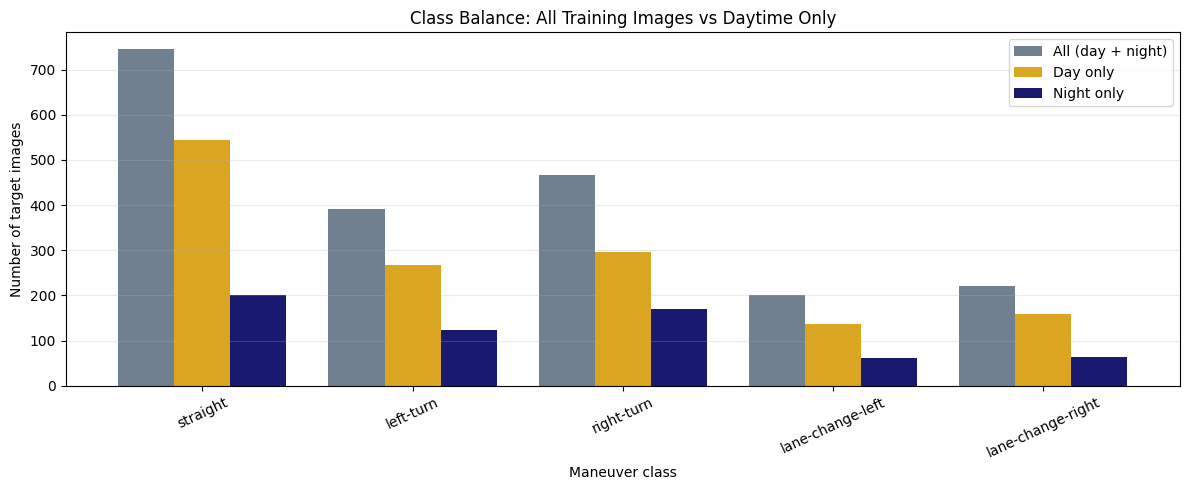

In [5]:
class_balance = pd.DataFrame(
    {
        'All (day + night)': [
            np.sum(labels_all == cls) for cls in CLASSES
        ],
        'Day only': [
            np.sum(labels_all[day_mask] == cls) for cls in CLASSES
        ],
        'Night only': [
            np.sum(labels_all[night_mask] == cls) for cls in CLASSES
        ],
    },
    index=CLASSES
)

display(class_balance)

ax = class_balance.plot(
    kind='bar',
    figsize=(12, 5),
    color=['slategray', 'goldenrod', 'midnightblue'],
    width=0.8
)

ax.set_title('Class Balance: All Training Images vs Daytime Only')
ax.set_xlabel('Maneuver class')
ax.set_ylabel('Number of target images')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig(
    FEATURES_DIR / 'class_balance_v2.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

## Save daytime-only feature arrays

Only rows classified as daytime are selected. The original feature filenames and the `_v2` filenames are checked for overlap before anything is written.

In [6]:
v2_arrays = {
    'hog': features_all['hog'][day_mask],
    'hsv': features_all['hsv'][day_mask],
    'labels': labels_all[day_mask],
    'road': features_all['road'][day_mask],
    'seq_ids': seq_ids_all[day_mask],
    'yolo': features_all['yolo'][day_mask],
}

v2_row_counts = {name: len(values) for name, values in v2_arrays.items()}

if len(set(v2_row_counts.values())) != 1:
    raise ValueError(f'V2 feature arrays are not aligned: {v2_row_counts}')

# Save only to the new filenames listed in V2_FILES.
for name, values in v2_arrays.items():
    output_path = FEATURES_DIR / V2_FILES[name]

    if output_path.name in ORIGINAL_FILES.values():
        raise RuntimeError(f'Refusing to overwrite original file: {output_path}')

    np.save(output_path, values)

# Reload array headers and verify the row counts written to disk.
for name, filename in V2_FILES.items():
    saved = np.load(
        FEATURES_DIR / filename,
        allow_pickle=name in {'labels', 'seq_ids'},
        mmap_mode=None if name in {'labels', 'seq_ids'} else 'r'
    )
    assert len(saved) == v2_row_counts[name]

print('Saved daytime-only arrays without changing the originals:')
for name, filename in V2_FILES.items():
    print(f'  {filename:<15} {v2_arrays[name].shape}')

Saved daytime-only arrays without changing the originals:
  hog_v2.npy      (1405, 5796)
  hsv_v2.npy      (1405, 34)
  labels_v2.npy   (1405,)
  road_v2.npy     (1405, 8)
  seq_ids_v2.npy  (1405,)
  yolo_v2.npy     (1405, 32)


## PCA comparison

Each column uses one feature set. PCA and standardization are fit once on all five-class rows, then the daytime subset is projected through the same fitted transforms. Because both rows use the same coordinate system, shifts and overlap can be compared directly.

- **Top row:** all target images; circles are day and x-marks are night.
- **Bottom row:** daytime-only target images.
- **Color:** maneuver class.

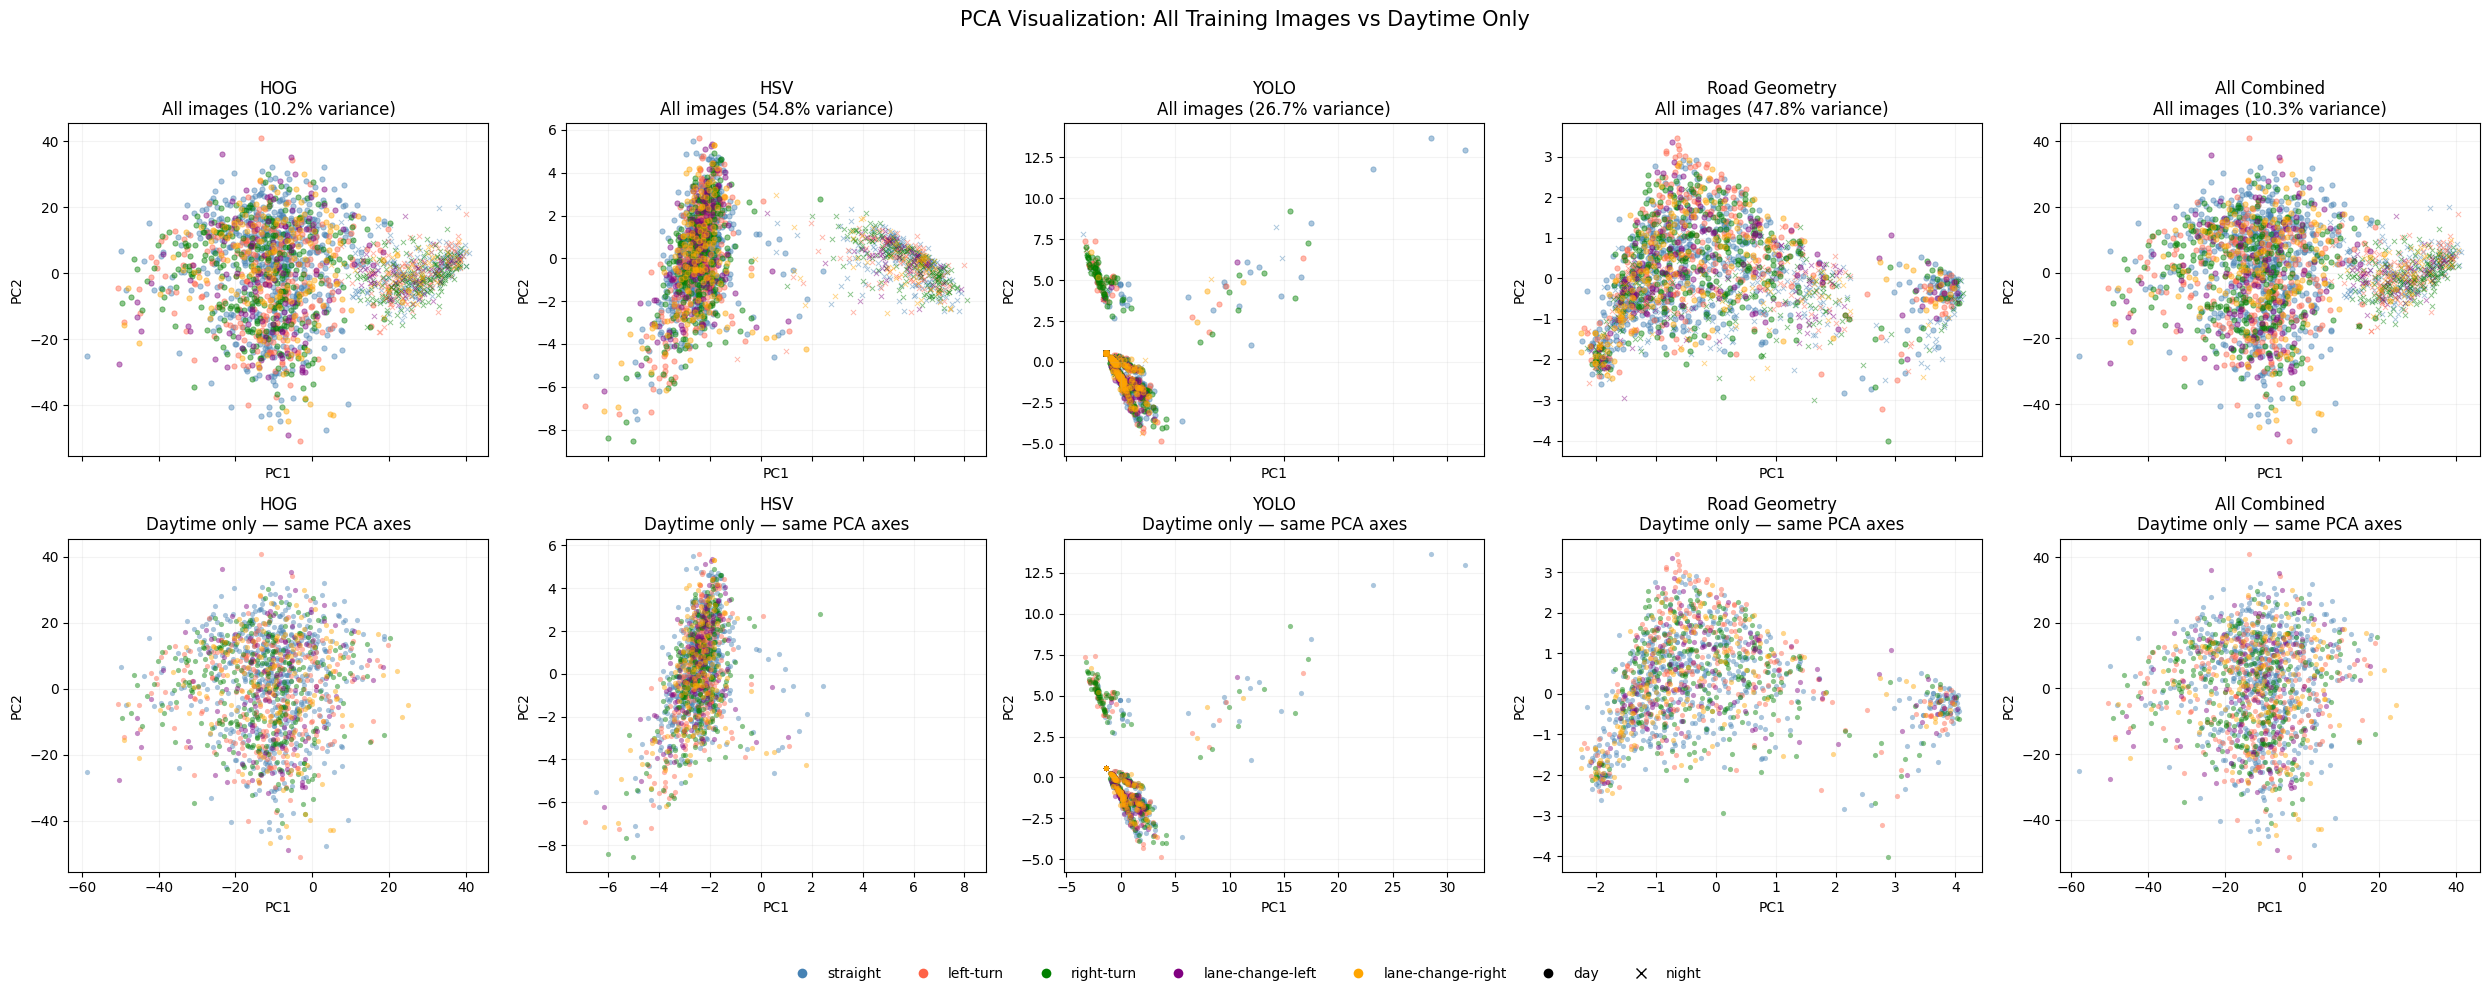

,feature_set,pc1_variance_percent,pc2_variance_percent,total_variance_percent
0,HOG,7.13,3.04,10.17
1,HSV,42.95,11.88,54.82
2,YOLO,14.73,11.93,26.66
3,Road Geometry,30.95,16.87,47.82
4,All Combined,7.24,3.03,10.27


In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D


feature_sets_all = {
    'HOG': features_all['hog'],
    'HSV': features_all['hsv'],
    'YOLO': features_all['yolo'],
    'Road Geometry': features_all['road'],
    'All Combined': np.concatenate([
        features_all['hog'],
        features_all['hsv'],
        features_all['yolo'],
        features_all['road'],
    ], axis=1),
}

feature_sets_day = {
    'HOG': v2_arrays['hog'],
    'HSV': v2_arrays['hsv'],
    'YOLO': v2_arrays['yolo'],
    'Road Geometry': v2_arrays['road'],
    'All Combined': np.concatenate([
        v2_arrays['hog'],
        v2_arrays['hsv'],
        v2_arrays['yolo'],
        v2_arrays['road'],
    ], axis=1),
}

labels_day = v2_arrays['labels']
lighting_markers = {'day': 'o', 'night': 'x'}

fig, axes = plt.subplots(
    2,
    len(feature_sets_all),
    figsize=(25, 10),
    sharex='col',
    sharey='col'
)

pca_rows = []

for col, (name, all_features) in enumerate(feature_sets_all.items()):
    day_features = feature_sets_day[name]

    # Fit once on all rows so the two panels use identical PCA axes.
    scaler = StandardScaler()
    all_scaled = scaler.fit_transform(all_features)
    day_scaled = scaler.transform(day_features)

    pca = PCA(
        n_components=2,
        svd_solver='randomized',
        random_state=RANDOM_STATE
    )
    all_projected = pca.fit_transform(all_scaled)
    day_projected = pca.transform(day_scaled)
    variance_explained = pca.explained_variance_ratio_.sum() * 100

    pca_rows.append({
        'feature_set': name,
        'pc1_variance_percent': pca.explained_variance_ratio_[0] * 100,
        'pc2_variance_percent': pca.explained_variance_ratio_[1] * 100,
        'total_variance_percent': variance_explained,
    })

    top_ax = axes[0, col]
    bottom_ax = axes[1, col]

    # Top row: show both maneuver class and lighting condition.
    for cls in CLASSES:
        for light, marker in lighting_markers.items():
            mask = (labels_all == cls) & (lighting_all == light)
            top_ax.scatter(
                all_projected[mask, 0],
                all_projected[mask, 1],
                c=COLORS[cls],
                marker=marker,
                alpha=0.45,
                s=14,
                linewidths=0.7
            )

        # Bottom row: only daytime points, using the same PCA axes.
        day_class_mask = labels_day == cls
        bottom_ax.scatter(
            day_projected[day_class_mask, 0],
            day_projected[day_class_mask, 1],
            c=COLORS[cls],
            marker='o',
            alpha=0.45,
            s=14,
            linewidths=0
        )

    top_ax.set_title(
        f'{name}\nAll images ({variance_explained:.1f}% variance)'
    )
    bottom_ax.set_title(f'{name}\nDaytime only — same PCA axes')

    top_ax.set_xlabel('PC1')
    top_ax.set_ylabel('PC2')
    bottom_ax.set_xlabel('PC1')
    bottom_ax.set_ylabel('PC2')

    top_ax.grid(alpha=0.15)
    bottom_ax.grid(alpha=0.15)

class_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        markerfacecolor=COLORS[cls],
        markeredgecolor='none',
        label=cls,
        markersize=7
    )
    for cls in CLASSES
]

lighting_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='black',
        linestyle='None',
        label='day',
        markersize=6
    ),
    Line2D(
        [0], [0],
        marker='x',
        color='black',
        linestyle='None',
        label='night',
        markersize=7
    ),
]

fig.suptitle(
    'PCA Visualization: All Training Images vs Daytime Only',
    fontsize=15
)
fig.legend(
    handles=class_handles + lighting_handles,
    loc='lower center',
    ncol=7,
    frameon=False
)

plt.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.savefig(
    FEATURES_DIR / 'pca_visualization_v2.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

pca_summary = pd.DataFrame(pca_rows)
pca_summary.to_csv(FEATURES_DIR / 'pca_summary_v2.csv', index=False)
display(pca_summary.round(2))

## Predictive comparison

PCA is descriptive, so the next sections use out-of-fold predictions from a class-balanced stochastic linear SVM. Three folds are used because HOG has 5,796 dimensions; this provides useful held-out estimates without the long runtime of repeatedly fitting the exact linear SVM solver.

Two different questions are evaluated:

1. **Does a feature perform worse at night?** The model is trained on all data through stratified cross-validation, then its held-out predictions are scored separately for day and night. For example, “HOG failure rate” means the misclassification rate of a model using only HOG—not a failure to calculate the HOG vector.
2. **Does daytime-only training improve a class such as `right-turn`?** For every fold, an all-data model and a daytime-only model predict the exact same held-out daytime rows. This controls the test examples while changing only the training data.

In [8]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_recall_fscore_support,
)


def get_n_splits(y, requested_splits=3):
    """Use as many folds as possible without emptying the smallest class."""
    smallest_class = min(Counter(y).values())
    n_splits = min(requested_splits, smallest_class)

    if n_splits < 2:
        raise ValueError('At least two examples per class are required.')

    return n_splits


def make_classifier(X=None):
    """
    Build a fast, scaled, class-balanced stochastic linear SVM.

    SGD trains a linear decision boundary like LinearSVC, but processes
    small batches of rows instead of repeatedly solving the full problem.
    Early stopping prevents unnecessary passes through high-dimensional HOG.
    """
    return make_pipeline(
        StandardScaler(),
        SGDClassifier(
            loss='hinge',
            penalty='l2',
            alpha=1e-4,
            class_weight='balanced',
            max_iter=2000,
            tol=1e-3,
            early_stopping=True,
            validation_fraction=0.10,
            n_iter_no_change=5,
            average=True,
            random_state=RANDOM_STATE
        )
    )


def cross_validated_predictions(X, y, cv, feature_name):
    """Generate out-of-fold predictions and report each fold's runtime."""
    predictions = np.empty(len(y), dtype=y.dtype)
    splits = list(cv.split(X, y))

    for fold, (train_indices, test_indices) in enumerate(splits, start=1):
        fold_start = time.time()
        model = make_classifier(X[train_indices])
        model.fit(X[train_indices], y[train_indices])
        predictions[test_indices] = model.predict(X[test_indices])

        fold_seconds = time.time() - fold_start
        print(
            f'  {feature_name} fold {fold}/{len(splits)} '
            f'completed in {fold_seconds:.1f} seconds'
        )

    return predictions


def overall_metrics(y_true, y_pred):
    """Return the three summary metrics used throughout the comparison."""
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(
            y_true,
            y_pred,
            labels=CLASSES,
            average='macro',
            zero_division=0
        ),
        'error_rate': 1 - accuracy_score(y_true, y_pred),
    }


def class_metrics(y_true, y_pred):
    """Return precision, recall, and F1 in the fixed CLASSES order."""
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=CLASSES,
        zero_division=0
    )

    return pd.DataFrame({
        'class': CLASSES,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'support': support,
    })

### 1. Feature performance during day vs night

The same out-of-fold predictions are split by lighting condition after prediction. A higher error rate at night indicates that the feature-only model misclassifies nighttime target images more often.

Cross-validating HOG...
  HOG fold 1/3 completed in 1.5 seconds
  HOG fold 2/3 completed in 1.1 seconds
  HOG fold 3/3 completed in 1.4 seconds
Cross-validating HSV...
  HSV fold 1/3 completed in 0.0 seconds
  HSV fold 2/3 completed in 0.0 seconds
  HSV fold 3/3 completed in 0.0 seconds
Cross-validating YOLO...
  YOLO fold 1/3 completed in 0.0 seconds
  YOLO fold 2/3 completed in 0.0 seconds
  YOLO fold 3/3 completed in 0.0 seconds
Cross-validating Road Geometry...
  Road Geometry fold 1/3 completed in 0.0 seconds
  Road Geometry fold 2/3 completed in 0.0 seconds
  Road Geometry fold 3/3 completed in 0.0 seconds
Cross-validating All Combined...
  All Combined fold 1/3 completed in 0.9 seconds
  All Combined fold 2/3 completed in 0.8 seconds
  All Combined fold 3/3 completed in 1.3 seconds
Completed lighting comparison in 7.5 seconds


,feature_set,lighting,n_test_rows,accuracy,balanced_accuracy,macro_f1,error_rate
0,All Combined,day,1405,0.432,0.410,0.395,0.568
1,All Combined,night,621,0.412,0.396,0.381,0.588
2,HOG,day,1405,0.431,0.402,0.393,0.569
3,HOG,night,621,0.420,0.409,0.395,0.580
4,HSV,day,1405,0.338,0.213,0.189,0.662
5,HSV,night,621,0.306,0.222,0.204,0.694
6,Road Geometry,day,1405,0.363,0.240,0.207,0.637
7,Road Geometry,night,621,0.314,0.224,0.186,0.686
8,YOLO,day,1405,0.371,0.258,0.241,0.629
9,YOLO,night,621,0.316,0.227,0.197,0.684


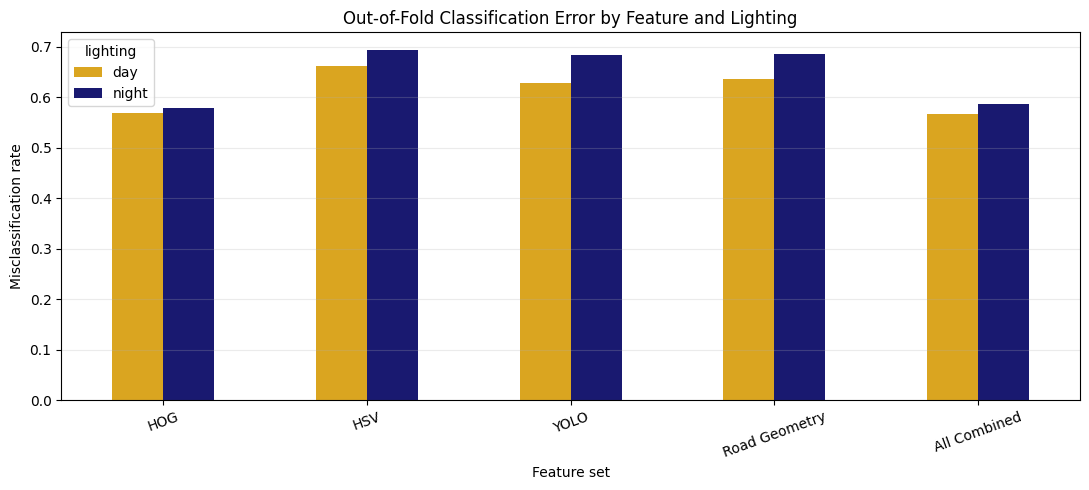

HOG-only misclassification is 1.1% higher at night (58.0%) than during the day (56.9%).


In [9]:
all_oof_predictions = {}
lighting_performance_rows = []
lighting_class_rows = []

n_splits_all = get_n_splits(labels_all, CV_FOLDS)
cv_all = StratifiedKFold(
    n_splits=n_splits_all,
    shuffle=True,
    random_state=RANDOM_STATE
)

start = time.time()

for name, X in feature_sets_all.items():
    print(f'Cross-validating {name}...')

    predictions = cross_validated_predictions(
        X=X,
        y=labels_all,
        cv=cv_all,
        feature_name=name
    )
    all_oof_predictions[name] = predictions

    for light in ['day', 'night']:
        light_mask = lighting_all == light
        metrics = overall_metrics(
            labels_all[light_mask],
            predictions[light_mask]
        )

        lighting_performance_rows.append({
            'feature_set': name,
            'lighting': light,
            'n_test_rows': int(light_mask.sum()),
            **metrics,
        })

        per_class = class_metrics(
            labels_all[light_mask],
            predictions[light_mask]
        )
        per_class['feature_set'] = name
        per_class['lighting'] = light
        lighting_class_rows.append(per_class)

elapsed = time.time() - start
print(f'Completed lighting comparison in {elapsed:.1f} seconds')

lighting_performance = pd.DataFrame(lighting_performance_rows)
lighting_class_performance = pd.concat(
    lighting_class_rows,
    ignore_index=True
)

lighting_performance.to_csv(
    FEATURES_DIR / 'lighting_performance_v2.csv',
    index=False
)
lighting_class_performance.to_csv(
    FEATURES_DIR / 'lighting_class_performance_v2.csv',
    index=False
)

display(
    lighting_performance.sort_values(['feature_set', 'lighting'])
    .reset_index(drop=True)
    .round(3)
)

# Plot the direct feature failure comparison by lighting condition.
error_table = lighting_performance.pivot(
    index='feature_set',
    columns='lighting',
    values='error_rate'
).reindex(feature_sets_all.keys())

ax = error_table.plot(
    kind='bar',
    figsize=(11, 5),
    color={'day': 'goldenrod', 'night': 'midnightblue'}
)
ax.set_title('Out-of-Fold Classification Error by Feature and Lighting')
ax.set_xlabel('Feature set')
ax.set_ylabel('Misclassification rate')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig(
    FEATURES_DIR / 'feature_error_by_lighting_v2.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

# Answer the HOG question directly from the out-of-fold results.
hog_errors = error_table.loc['HOG']
hog_gap = hog_errors['night'] - hog_errors['day']

if hog_gap > 0:
    print(
        f'HOG-only misclassification is {hog_gap:.1%} higher at night '
        f'({hog_errors["night"]:.1%}) than during the day '
        f'({hog_errors["day"]:.1%}).'
    )
elif hog_gap < 0:
    print(
        f'HOG-only misclassification is {-hog_gap:.1%} lower at night '
        f'({hog_errors["night"]:.1%}) than during the day '
        f'({hog_errors["day"]:.1%}).'
    )
else:
    print('HOG-only misclassification is equal for day and night rows.')

### 2. All-data training vs daytime-only training

Both models below are scored on the same held-out daytime rows in every fold:

- **All day + night training:** remaining daytime rows plus all nighttime rows.
- **Day-only training:** only the remaining daytime rows.

This comparison is more informative than comparing two unrelated train/test splits because the test images are identical for both models.

In [10]:
def predict_same_day_folds(
    X, y, lighting, requested_splits=3, feature_name='feature'
):
    """
    Compare all-data and day-only training on identical daytime test folds.

    Night rows are never included in the test set for this comparison.
    """
    day_indices = np.flatnonzero(lighting == 'day')
    night_indices = np.flatnonzero(lighting == 'night')
    y_day = y[day_indices]

    n_splits = get_n_splits(y_day, requested_splits)
    cv_day = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    predictions_all_training = np.empty(len(day_indices), dtype=y.dtype)
    predictions_day_training = np.empty(len(day_indices), dtype=y.dtype)

    day_splits = list(cv_day.split(X[day_indices], y_day))

    for fold, (train_day_relative, test_day_relative) in enumerate(
        day_splits,
        start=1
    ):
        fold_start = time.time()
        train_day_global = day_indices[train_day_relative]
        test_day_global = day_indices[test_day_relative]

        # The all-data model adds all nighttime rows to the same daytime
        # training fold. The held-out daytime rows are excluded from both.
        train_all_global = np.concatenate([
            train_day_global,
            night_indices
        ])

        all_training_model = make_classifier(X[train_all_global])
        all_training_model.fit(
            X[train_all_global],
            y[train_all_global]
        )
        predictions_all_training[test_day_relative] = (
            all_training_model.predict(X[test_day_global])
        )

        day_training_model = make_classifier(X[train_day_global])
        day_training_model.fit(
            X[train_day_global],
            y[train_day_global]
        )
        predictions_day_training[test_day_relative] = (
            day_training_model.predict(X[test_day_global])
        )

        fold_seconds = time.time() - fold_start
        print(
            f'  {feature_name} fold {fold}/{len(day_splits)} '
            f'completed in {fold_seconds:.1f} seconds'
        )

    return y_day, predictions_all_training, predictions_day_training


day_test_performance_rows = []
day_test_class_rows = []
paired_day_predictions = {}

start = time.time()

for name, X in feature_sets_all.items():
    print(f'Comparing training sets for {name}...')

    y_day_test, pred_all_training, pred_day_training = predict_same_day_folds(
        X=X,
        y=labels_all,
        lighting=lighting_all,
        requested_splits=CV_FOLDS,
        feature_name=name
    )

    paired_day_predictions[name] = {
        'true': y_day_test,
        'All day + night training': pred_all_training,
        'Day-only training': pred_day_training,
    }

    for training_set, predictions in [
        ('All day + night training', pred_all_training),
        ('Day-only training', pred_day_training),
    ]:
        metrics = overall_metrics(y_day_test, predictions)
        day_test_performance_rows.append({
            'feature_set': name,
            'training_set': training_set,
            'n_day_test_rows': len(y_day_test),
            **metrics,
        })

        per_class = class_metrics(y_day_test, predictions)
        per_class['feature_set'] = name
        per_class['training_set'] = training_set
        day_test_class_rows.append(per_class)

elapsed = time.time() - start
print(f'Completed paired daytime tests in {elapsed:.1f} seconds')

day_test_performance = pd.DataFrame(day_test_performance_rows)
day_test_class_performance = pd.concat(
    day_test_class_rows,
    ignore_index=True
)

day_test_performance.to_csv(
    FEATURES_DIR / 'day_test_performance_v2.csv',
    index=False
)
day_test_class_performance.to_csv(
    FEATURES_DIR / 'day_test_class_performance_v2.csv',
    index=False
)

display(
    day_test_performance.sort_values(['feature_set', 'training_set'])
    .reset_index(drop=True)
    .round(3)
)

Comparing training sets for HOG...
  HOG fold 1/3 completed in 1.7 seconds
  HOG fold 2/3 completed in 1.9 seconds
  HOG fold 3/3 completed in 1.9 seconds
Comparing training sets for HSV...
  HSV fold 1/3 completed in 0.1 seconds
  HSV fold 2/3 completed in 0.1 seconds
  HSV fold 3/3 completed in 0.1 seconds
Comparing training sets for YOLO...
  YOLO fold 1/3 completed in 0.1 seconds
  YOLO fold 2/3 completed in 0.1 seconds
  YOLO fold 3/3 completed in 0.1 seconds
Comparing training sets for Road Geometry...
  Road Geometry fold 1/3 completed in 0.1 seconds
  Road Geometry fold 2/3 completed in 0.1 seconds
  Road Geometry fold 3/3 completed in 0.1 seconds
Comparing training sets for All Combined...
  All Combined fold 1/3 completed in 1.5 seconds
  All Combined fold 2/3 completed in 2.3 seconds
  All Combined fold 3/3 completed in 2.1 seconds
Completed paired daytime tests in 12.1 seconds


,feature_set,training_set,n_day_test_rows,accuracy,balanced_accuracy,macro_f1,error_rate
0,All Combined,All day + night training,1405,0.436,0.416,0.402,0.564
1,All Combined,Day-only training,1405,0.413,0.398,0.384,0.587
2,HOG,All day + night training,1405,0.429,0.402,0.392,0.571
3,HOG,Day-only training,1405,0.404,0.390,0.376,0.596
4,HSV,All day + night training,1405,0.330,0.222,0.210,0.670
5,HSV,Day-only training,1405,0.314,0.228,0.222,0.686
6,Road Geometry,All day + night training,1405,0.377,0.236,0.200,0.623
7,Road Geometry,Day-only training,1405,0.355,0.228,0.201,0.645
8,YOLO,All day + night training,1405,0.364,0.253,0.246,0.636
9,YOLO,Day-only training,1405,0.347,0.262,0.254,0.653


## Feature and class differences

The first plot isolates `right-turn`. The heatmap then shows the daytime-only minus all-data recall difference for every feature and class. Positive values mean daytime-only training improved recall on the common daytime test folds; negative values mean including nighttime training examples helped.

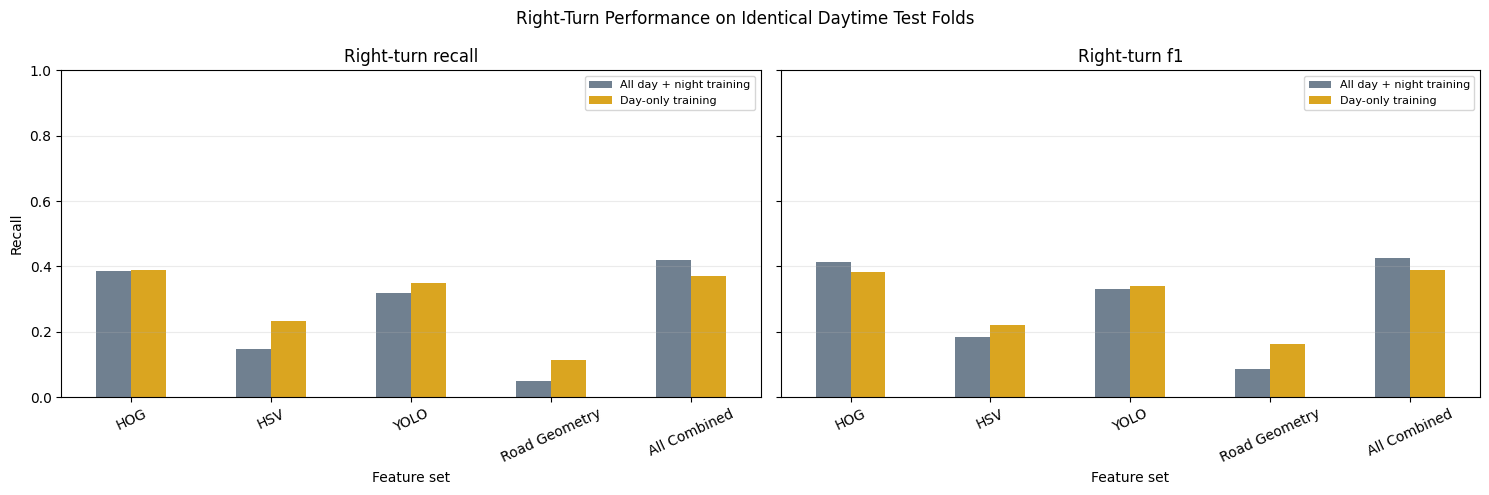

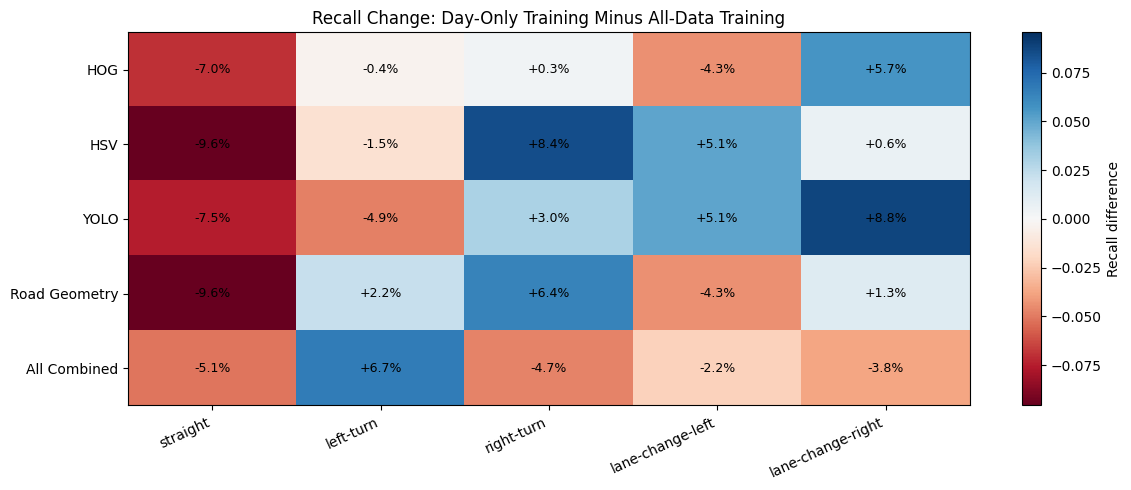

class,straight,left-turn,right-turn,lane-change-left,lane-change-right
feature_set,,,,,
HOG,-0.070,-0.004,0.003,-0.043,0.057
HSV,-0.096,-0.015,0.084,0.051,0.006
YOLO,-0.075,-0.049,0.030,0.051,0.088
Road Geometry,-0.096,0.022,0.064,-0.043,0.013
All Combined,-0.051,0.067,-0.047,-0.022,-0.038


Right-turn recall change on daytime test rows:
  HOG            improved       by 0.3%
  HSV            improved       by 8.4%
  YOLO           improved       by 3.0%
  Road Geometry  improved       by 6.4%
  All Combined   decreased      by 4.7%


In [11]:
right_turn_results = (
    day_test_class_performance[
        day_test_class_performance['class'] == 'right-turn'
    ]
    .copy()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, metric in zip(axes, ['recall', 'f1']):
    metric_table = right_turn_results.pivot(
        index='feature_set',
        columns='training_set',
        values=metric
    ).reindex(feature_sets_all.keys())

    metric_table.plot(
        kind='bar',
        ax=ax,
        color={
            'All day + night training': 'slategray',
            'Day-only training': 'goldenrod',
        }
    )
    ax.set_title(f'Right-turn {metric}')
    ax.set_xlabel('Feature set')
    ax.set_ylabel(metric.capitalize())
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.25)
    ax.legend(fontsize=8)

plt.suptitle('Right-Turn Performance on Identical Daytime Test Folds')
plt.tight_layout()
plt.savefig(
    FEATURES_DIR / 'right_turn_performance_v2.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

# Calculate the change in recall caused by using only daytime training rows.
recall_table = day_test_class_performance.pivot_table(
    index=['feature_set', 'class'],
    columns='training_set',
    values='recall'
)

recall_delta = (
    recall_table['Day-only training'] -
    recall_table['All day + night training']
).unstack('class')

recall_delta = recall_delta.reindex(
    index=feature_sets_all.keys(),
    columns=CLASSES
)

max_abs_delta = np.nanmax(np.abs(recall_delta.to_numpy()))
color_limit = max(max_abs_delta, 0.01)

fig, ax = plt.subplots(figsize=(12, 5))
heatmap = ax.imshow(
    recall_delta.to_numpy(),
    cmap='RdBu',
    vmin=-color_limit,
    vmax=color_limit,
    aspect='auto'
)

ax.set_xticks(range(len(CLASSES)))
ax.set_xticklabels(CLASSES, rotation=25, ha='right')
ax.set_yticks(range(len(recall_delta.index)))
ax.set_yticklabels(recall_delta.index)
ax.set_title('Recall Change: Day-Only Training Minus All-Data Training')

for row in range(recall_delta.shape[0]):
    for col in range(recall_delta.shape[1]):
        value = recall_delta.iloc[row, col]
        ax.text(
            col,
            row,
            f'{value:+.1%}',
            ha='center',
            va='center',
            color='black',
            fontsize=9
        )

colorbar = fig.colorbar(heatmap, ax=ax)
colorbar.set_label('Recall difference')

plt.tight_layout()
plt.savefig(
    FEATURES_DIR / 'class_recall_delta_v2.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

display(recall_delta.round(3))

# Print a direct answer for right-turn for each feature set.
print('Right-turn recall change on daytime test rows:')

for feature_name in feature_sets_all:
    change = recall_delta.loc[feature_name, 'right-turn']

    if change > 0:
        conclusion = 'improved'
    elif change < 0:
        conclusion = 'decreased'
    else:
        conclusion = 'did not change'

    print(
        f'  {feature_name:<14} {conclusion:<14} '
        f'by {abs(change):.1%}'
    )

## Interpretation notes

- A night/day error gap indicates an association between lighting and model performance; it does not prove that lighting alone caused the difference.
- The PCA plot is useful for visualizing overlap and distribution shift, but classification metrics should be used to judge prediction quality.
- The paired daytime test comparison holds test images constant. This is the appropriate table for deciding whether daytime-only training helps `right-turn` or any other class.
- Daytime filtering changes both sample size and class balance. Review the class-balance plot alongside the recall heatmap before choosing which training set to use.
- If the `0.30` threshold is changed, rerun the notebook from the day/night classification section so the `_v2` arrays and every comparison remain aligned.